#### Data Analysis project

####  data collection
 ### data cleaning
### EDA (Exploratory Data Analysis)
### insight and conclusion



In [1]:
# india ecommerce sales and Customer Analytics using python 

# India E-Commerce Sales & Customer Analytics Using Python

**An end-to-end exploratory data analysis of 15,000+ online orders placed across 18 Indian states**

---

| | |
|---|---|
| **Domain** | Retail / E-Commerce Analytics |
| **Tools** | Python, NumPy, Pandas, Matplotlib, Seaborn, Plotly |
| **Dataset** | `india_ecommerce_sales.csv` (synthetic, 15,120 rows x 29 columns) |
| **Period covered** | 01-Jan-2024 to 31-Dec-2025 (24 months) |
| **Currency** | Indian Rupee (INR) |
| **Deliverables** | This notebook, a PDF report, a PowerPoint deck and exported charts |

---


## 1. Business Problem

**BharatKart Retail Pvt. Ltd.** is a mid-sized Indian e-commerce marketplace selling across
eight categories in 25 cities. Over the last two years the company has grown its top line
aggressively through heavy festive discounting and rapid category expansion.

Management is now facing an uncomfortable situation:

> *"Revenue keeps growing, but profit is not growing at the same pace. We do not know which
> categories, which regions and which customers are actually making money for us."*

The leadership team cannot answer basic questions such as *which state is most profitable*,
*how much margin our discounts destroy*, or *why our customer ratings are falling in some
regions*. Decisions are being taken on intuition rather than evidence.



## 2. Project Objectives

1. Load, inspect and **clean** a realistic (deliberately messy) transactional dataset.
2. Engineer time, customer and pricing features that make the data analysis-ready.
3. Compute the **core KPIs** management needs on a single page.
4. Run a structured **exploratory data analysis** (univariate, bivariate, multivariate).
5. Quantify **which categories, products, regions and customers drive revenue and profit**.
6. Measure the **impact of discounting** on profitability.
7. Measure the **impact of delivery performance** on customer satisfaction.
8. Map performance **geographically across India**.
9. Segment customers using an **RFM** model.
10. Convert every finding into **actionable business recommendations**.





### Data dictionary

| Column | Type | Description |
|---|---|---|
| `Order_ID` | object | Unique identifier of the order |
| `Order_Date` | date | Date the order was placed |
| `Customer_ID` | object | Unique identifier of the customer |
| `Customer_Name` | object | Customer full name |
| `Gender` | object | Male / Female |
| `Age` | float | Age of the customer in years |
| `Age_Group` | object | Age bucket (18-25, 26-35, 36-45, 46-60, 60+) |
| `City` | object | Delivery city |
| `State` | object | Delivery state |
| `Region` | object | North / South / East / West / Central / Northeast |
| `Latitude` | float | Latitude of the city (for mapping) |
| `Longitude` | float | Longitude of the city (for mapping) |
| `Product_ID` | object | Unique identifier of the product |
| `Product_Name` | object | Product name |
| `Category` | object | One of 8 merchandising categories |
| `Sub_Category` | object | Sub-category within the category |
| `Quantity` | int | Units ordered |
| `Unit_Price` | float | Listed price per unit before discount (INR) |
| `Discount_Percentage` | float | Discount applied on the order (%) |
| `Sales` | float | Net booked revenue after discount (INR) |
| `Cost` | float | Cost of goods sold (INR) |
| `Profit` | float | Sales minus Cost, adjusted for returns (INR) |
| `Profit_Margin` | float | Profit as a percentage of Sales |
| `Payment_Method` | object | UPI, Credit Card, COD, EMI, ... |
| `Order_Status` | object | Delivered / Shipped / Returned / Cancelled |
| `Delivery_Days` | float | Days between order and delivery |
| `Customer_Rating` | float | Post-delivery rating on a 1-5 scale |
| `Customer_Segment` | object | Premium / Regular / Budget / Corporate |
| `Device_Type` | object | Channel used to place the order |

> **Note on synthetic data.** The dataset was produced by `scripts/generate_dataset.py`
> with a fixed random seed, so every number in this notebook is reproducible. Realistic
> behavioural patterns (festive peaks, discount-driven margin erosion, fashion returns,
> delivery-rating relationship) were built into the generator; the analysis below
> *discovers* them the same way it would on real data.





## 4. Technologies Used

| Library | Why it is used here |
|---|---|
| **NumPy** | Fast vectorised numeric work, percentiles, conditional flags |
| **Pandas** | Loading, cleaning, grouping, pivoting, time-series resampling |
| **Matplotlib** | Static charts for the report and presentation |
| **Seaborn** | Statistical charts (distributions, box plots, heatmaps) |
| **Plotly Express** | Interactive charts and the India geographic map |
| **Jupyter Notebook** | The analysis environment itself |


In [2]:
# step-1 Data collection

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import json,os,warnings
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")





In [4]:
df_raw = pd.read_csv('india_ecommerce_sales.csv')

In [5]:
df_raw.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23.00,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,UPI,Delivered,5.00,4.20,Premium,Mobile App
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44.00,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window AC,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3.00,4.50,Corporate,Mobile App
2,ORD109386,2025-05-15,CUST11826,Karan Deshmukh,Female,38.00,36-45,NaN,Gujarat,West,21.17,72.83,P1058,Data Science Handbook,Books,Academic,3,"1,733.50",7.90,"4,791.23","3,946.73",844.50,17.63,UPI,Delivered,2.00,4.80,Regular,Mobile Web
3,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32.00,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3.00,5.00,Premium,Tablet
4,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42.00,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women's Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash on Delivery,Returned,5.00,2.90,Regular,Mobile App


In [6]:
df_raw.shape

(15120, 29)

In [7]:
# step-2 Data cleaning


In [8]:
for i in df_raw.columns:
    print(i)
 

Order_ID
Order_Date
Customer_ID
Customer_Name
Gender
Age
Age_Group
City
State
Region
Latitude
Longitude
Product_ID
Product_Name
Category
Sub_Category
Quantity
Unit_Price
Discount_Percentage
Sales
Cost
Profit
Profit_Margin
Payment_Method
Order_Status
Delivery_Days
Customer_Rating
Customer_Segment
Device_Type


In [9]:
df_raw.isnull().sum()

Order_ID                 0
Order_Date               0
Customer_ID              0
Customer_Name            0
Gender                 151
Age                    231
Age_Group                0
City                    91
State                    0
Region                   0
Latitude                 0
Longitude                0
Product_ID               0
Product_Name             0
Category                 0
Sub_Category             0
Quantity                 0
Unit_Price               0
Discount_Percentage      0
Sales                    0
Cost                     0
Profit                   0
Profit_Margin            0
Payment_Method         121
Order_Status             0
Delivery_Days          303
Customer_Rating        625
Customer_Segment         0
Device_Type              0
dtype: int64

In [10]:
# anther method
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             15120 non-null  str    
 1   Order_Date           15120 non-null  str    
 2   Customer_ID          15120 non-null  str    
 3   Customer_Name        15120 non-null  str    
 4   Gender               14969 non-null  str    
 5   Age                  14889 non-null  float64
 6   Age_Group            15120 non-null  str    
 7   City                 15029 non-null  str    
 8   State                15120 non-null  str    
 9   Region               15120 non-null  str    
 10  Latitude             15120 non-null  float64
 11  Longitude            15120 non-null  float64
 12  Product_ID           15120 non-null  str    
 13  Product_Name         15120 non-null  str    
 14  Category             15120 non-null  str    
 15  Sub_Category         15120 non-null  str    
 1

**What `.info()` tells us**

* The file has **15,120 rows**, but several columns have fewer non-null values -
  `Customer_Rating`, `Delivery_Days`, `Age`, `Gender`, `Payment_Method` and `City`
  all contain missing data.
* `Order_Date` was read as **object (text)**, not as a date. Until we convert it we cannot
  do any time-series work.
* `Age` and `Delivery_Days` are floats only because missing values force pandas to use
  `float64`; conceptually they are whole numbers.



In [11]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"14,889.00",34.29,10.59,1.00,27.00,34.00,41.00,200.00
Latitude,"15,120.00",20.36,6.07,8.52,13.08,20.30,26.45,30.90
Longitude,"15,120.00",77.55,4.10,72.57,73.86,77.10,78.49,91.74
Quantity,"15,120.00",1.95,4.59,-3.00,1.00,1.00,2.00,206.00
Unit_Price,"15,120.00","7,268.84","15,442.20",122.40,776.89,"1,910.14","5,191.51","890,296.75"
Discount_Percentage,"15,120.00",15.25,8.48,0.00,9.10,15.10,21.10,49.20
Sales,"15,120.00","8,168.42","15,406.42",109.87,"1,264.30","2,453.35","6,590.12","204,868.73"
Cost,"15,120.00","7,472.79","15,171.63",105.82,994.78,"1,958.74","5,279.10","219,886.83"
Profit,"15,120.00",542.32,"1,785.56","-23,504.19",53.63,337.51,873.48,"23,402.87"
Profit_Margin,"15,120.00",14.33,15.96,-51.78,3.73,14.78,26.14,51.39


**Red flags already visible in `.describe()`**

| Column | Suspicious value | Why it matters |
|---|---|---|
| `Quantity` | minimum is **negative** and maximum is in the hundreds | Negative units are impossible; huge quantities are data-entry glitches |
| `Age` | minimum near **1**, maximum **200** | Not a valid customer age |
| `Customer_Rating` | maximum above **5** | The rating scale is 1-5 |
| `Delivery_Days` | maximum near **60** | Almost certainly stuck/lost shipments |
| `Unit_Price` | maximum far above the highest catalogue price | Price-feed error |

We will handle each of these explicitly in the cleaning section.




In [12]:
# how many  unique values  each has and which value appers most often
df_raw.describe(include="object").T

C:\Users\Admin\AppData\Local\Temp\ipykernel_16932\258229763.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include="object").T


,count,unique,top,freq
Order_ID,15120,15000,ORD100264,2
Order_Date,15120,731,2025-10-05,52
Customer_ID,15120,3086,CUST12879,37
Customer_Name,15120,1212,Shruti Iyer,65
Gender,14969,6,Male,8060
Age_Group,15120,5,26-35,5019
City,15029,25,Mumbai,1454
State,15120,20,Maharashtra,3024
Region,15120,6,South,4835
Product_ID,15120,67,P1043,391


In [13]:
print("unique values per column")
df_raw.nunique().sort_values(ascending=False)

unique values per column


Order_ID               15000
Sales                  14837
Cost                   14807
Profit                 14477
Unit_Price             13953
Profit_Margin           5757
Customer_ID             3086
Customer_Name           1212
Order_Date               731
Discount_Percentage      420
Product_Name              67
Product_ID                67
Age                       54
Customer_Rating           39
Sub_Category              33
Quantity                  28
Longitude                 25
City                      25
Latitude                  25
State                     20
Delivery_Days             19
Category                  15
Payment_Method            12
Gender                     6
Region                     6
Age_Group                  5
Order_Status               4
Customer_Segment           4
Device_Type                4
dtype: int64

In [14]:
# handle null values

In [15]:
df_raw.dropna(inplace=True,ignore_index=True)

In [16]:
df_raw.isnull().sum().sum()

np.int64(0)

In [17]:
df_raw.shape

(13649, 29)

In [18]:
# change data types of date columns

In [19]:
df_raw['Order_Date']=pd.to_datetime(df_raw['Order_Date'])

In [20]:
df_raw.dtypes

Order_ID                          str
Order_Date             datetime64[us]
Customer_ID                       str
Customer_Name                     str
Gender                            str
Age                           float64
Age_Group                         str
City                              str
State                             str
Region                            str
Latitude                      float64
Longitude                     float64
Product_ID                        str
Product_Name                      str
Category                          str
Sub_Category                      str
Quantity                        int64
Unit_Price                    float64
Discount_Percentage           float64
Sales                         float64
Cost                          float64
Profit                        float64
Profit_Margin                 float64
Payment_Method                    str
Order_Status                      str
Delivery_Days                 float64
Customer_Rat

In [21]:
df_raw['age']=df_raw['Age'].astype('int64')
df_raw['Delivery_Days']=df_raw['Delivery_Days'].astype('int64')

In [22]:
df_raw.dtypes

Order_ID                          str
Order_Date             datetime64[us]
Customer_ID                       str
Customer_Name                     str
Gender                            str
Age                           float64
Age_Group                         str
City                              str
State                             str
Region                            str
Latitude                      float64
Longitude                     float64
Product_ID                        str
Product_Name                      str
Category                          str
Sub_Category                      str
Quantity                        int64
Unit_Price                    float64
Discount_Percentage           float64
Sales                         float64
Cost                          float64
Profit                        float64
Profit_Margin                 float64
Payment_Method                    str
Order_Status                      str
Delivery_Days                   int64
Customer_Rat

In [23]:
def get_unique(df):
    for i in df.columns:
        if df[i].dtype=='str':
            print(df[i].unique())

In [24]:
get_unique(df_raw[['Gender','Region']])

<StringArray>
['Female', 'Male', 'F', 'male', 'M', 'female']
Length: 6, dtype: str
<StringArray>
['South', 'North', 'West', 'Northeast', 'East', 'Central']
Length: 6, dtype: str


In [25]:
df_raw.duplicated().sum()

np.int64(109)

In [26]:
# 109 rows are duplicted

In [27]:
df_raw.drop_duplicates(inplace=True,ignore_index=True)

In [28]:
df_raw.shape

(13540, 30)

In [29]:
# order id

In [30]:
df_raw['Order_ID'].duplicated().sum()

np.int64(0)

In [31]:
# repalce values

In [32]:
df_raw.describe(include="object").T

C:\Users\Admin\AppData\Local\Temp\ipykernel_16932\3663497146.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include="object").T


,count,unique,top,freq
Order_ID,13540,13540,ORD101152,1
Customer_ID,13540,3022,CUST12879,32
Customer_Name,13540,1207,Shruti Iyer,62
Gender,13540,6,Male,7292
Age_Group,13540,5,26-35,4496
City,13540,25,Mumbai,1307
State,13540,20,Maharashtra,2709
Region,13540,6,South,4355
Product_ID,13540,67,P1043,349
Product_Name,13540,67,Bru Instant Coffee 200g,349


In [33]:
df_raw['Gender'].unique()

<StringArray>
['Female', 'Male', 'F', 'male', 'M', 'female']
Length: 6, dtype: str

In [34]:
df_raw=df_raw.replace({'Gender':{'F':'Female','M':'Male','male':'Male','female':'Female'}})


In [35]:
df_raw['Gender'].unique()


<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [36]:
df_raw.shape

(13540, 30)

In [37]:
get_unique(df_raw)

<StringArray>
['ORD101152', 'ORD107594', 'ORD102186', 'ORD113618', 'ORD109118', 'ORD104054', 'ORD101842', 'ORD109287', 'ORD106139', 'ORD101749',
 ...
 'ORD107567', 'ORD111450', 'ORD101373', 'ORD113928', 'ORD100920', 'ORD105700', 'ORD110743', 'ORD100538', 'ORD109413', 'ORD112464']
Length: 13540, dtype: str
<StringArray>
['CUST13416', 'CUST12988', 'CUST12825', 'CUST12560', 'CUST11485', 'CUST12272', 'CUST11168', 'CUST12020', 'CUST10513', 'CUST11617',
 ...
 'CUST10107', 'CUST13496', 'CUST10682', 'CUST13519', 'CUST13497', 'CUST12836', 'CUST12956', 'CUST13558', 'CUST10060', 'CUST11726']
Length: 3022, dtype: str
<StringArray>
[         'Tanvi Rao', 'Swapnil Chatterjee',       'Swapnil Bhat',       'Imran Sharma',      'Deepak Mishra',         'Harsh Bose',  'Shruti Chatterjee',
         'Yash Joshi',       'Farhan Patil',      'Rajesh Sharma',
 ...
         'Rahul Gill',      'Tejas Chauhan',  'Siddharth Chauhan',        'Karan Menon',       'Sanjana Nair',     'Arjun Kulkarni',       'Meera 

In [38]:
df_raw.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

### Remove Extra spaces for each text columns

In [39]:
text_cols = ["Gender", "City", "State", "Region", "Category", "Sub_Category",
             "Payment_Method", "Order_Status", "Customer_Segment", "Device_Type",
             "Product_Name", "Age_Group"]





In [40]:
for c in text_cols:
    df_raw[c] = df_raw[c].astype(str).str.strip()
    df_raw[c] = df_raw[c].replace({"nan": np.nan,"None": np.nan})

In [41]:
df_raw.isnull().sum().sum()

np.int64(0)

In [42]:
df_raw["Category"].unique()

<StringArray>
[         'Grocery',       'Appliances',          'Fashion', 'Home & Furniture',           'Beauty',      'Electronics',            'Books',
           'Sports',      'electronics',      'ELECTRONICS',          'grocery',          'fashion',          'GROCERY']
Length: 13, dtype: str

In [43]:
for c in text_cols:
    df_raw[c] = df_raw[c].str.title()

In [44]:
df_raw["Category"].unique()

<StringArray>
['Grocery', 'Appliances', 'Fashion', 'Home & Furniture', 'Beauty', 'Electronics', 'Books', 'Sports']
Length: 8, dtype: str

In [45]:
df_raw["Payment_Method"].unique()

<StringArray>
['Upi', 'Credit Card', 'Wallet', 'Cash On Delivery', 'Emi', 'Debit Card', 'Net Banking', 'Cod']
Length: 8, dtype: str

In [46]:
df_raw=df_raw.replace({'Payment_Method':{"Cod": "Cash On Delivery",
                                         'Cash on Delivery':'Cash On Delivery'}})



In [47]:
df_raw["Payment_Method"].unique()

<StringArray>
['Upi', 'Credit Card', 'Wallet', 'Cash On Delivery', 'Emi', 'Debit Card', 'Net Banking']
Length: 7, dtype: str

In [48]:
df_raw["Payment_Method"].unique()

<StringArray>
['Upi', 'Credit Card', 'Wallet', 'Cash On Delivery', 'Emi', 'Debit Card', 'Net Banking']
Length: 7, dtype: str

In [49]:
for i in df_raw['State'].unique():
    print(i)

Kerala
Haryana
Maharashtra
Uttar Pradesh
Assam
Odisha
Punjab
Tamil Nadu
Telangana
Karnataka
Delhi
Gujarat
West Bengal
Rajasthan
Madhya Pradesh
Chandigarh
Bihar


In [50]:
df_raw.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,13540,2025-01-31 21:55:46.883308,2024-01-01 00:00:00,2024-08-21 00:00:00,2025-01-25 12:00:00,2025-08-17 00:00:00,2025-12-31 00:00:00,NaN
Age,"13,540.00",34.29,1.00,27.00,34.00,41.00,200.00,10.63
Latitude,"13,540.00",20.34,8.52,13.08,19.08,26.45,30.90,6.08
Longitude,"13,540.00",77.54,72.57,73.86,77.10,78.49,91.74,4.08
Quantity,"13,540.00",1.95,-3.00,1.00,1.00,2.00,206.00,4.62
Unit_Price,"13,540.00","7,258.64",122.40,782.44,"1,919.74","5,224.56","890,296.75","15,626.47"
Discount_Percentage,"13,540.00",15.27,0.00,9.10,15.10,21.10,49.20,8.47
Sales,"13,540.00","8,148.09",115.39,"1,273.65","2,467.66","6,628.60","204,868.73","15,366.97"
Cost,"13,540.00","7,453.03",105.82,"1,003.49","1,970.96","5,348.60","219,886.83","15,126.06"
Profit,"13,540.00",541.02,"-23,504.19",53.47,336.13,874.27,"23,402.87","1,759.01"


In [51]:
df_raw=df_raw[~(df_raw["Quantity"]<=0)] 

In [52]:
df_raw.shape

(13535, 30)

In [53]:
df_raw[(df_raw["Age"] < 15) | (df_raw["Age"] > 90)]


,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type,age
150,ORD102769,2024-06-28,CUST12692,Ishita Joshi,Female,150.00,36-45,Delhi,Delhi,North,28.70,77.10,P1045,Mtr Ready To Eat Combo,Grocery,Packaged Food,1,584.45,0.00,584.45,491.81,92.64,15.85,Upi,Delivered,2,4.90,Premium,Mobile App,150
1199,ORD113766,2025-11-13,CUST11823,Swapnil Banerjee,Female,150.00,46-60,Kolkata,West Bengal,East,22.57,88.36,P1013,Us Polo Assn Polo T-Shirt,Fashion,Men'S Clothing,5,"1,792.40",27.50,"6,496.55","5,054.73","1,441.82",22.19,Credit Card,Delivered,3,4.70,Corporate,Mobile App,150
6781,ORD109778,2025-06-04,CUST10864,Gaurav Das,Female,150.00,26-35,Delhi,Delhi,North,28.70,77.10,P1036,Maybelline Fit Me Foundation,Beauty,Makeup,1,"1,103.58",4.40,"1,054.60",593.02,461.58,43.77,Upi,Delivered,5,3.60,Budget,Desktop,150
8173,ORD103025,2024-07-12,CUST10179,Rahul Sheikh,Female,1.00,36-45,Delhi,Delhi,North,28.70,77.10,P1066,Voltas 1.5T Split Ac,Appliances,Air Conditioners,2,"45,728.56",11.10,"81,288.04","72,424.00","8,864.04",10.90,Emi,Delivered,2,5.00,Regular,Mobile App,1
8685,ORD102582,2024-06-15,CUST12966,Harsh Chatterjee,Female,200.00,36-45,Pune,Maharashtra,West,18.52,73.86,P1030,Bombay Dyeing Bedsheet,Home & Furniture,Bedding,2,"1,486.31",11.20,"2,640.25","2,030.69",609.56,23.09,Upi,Delivered,5,4.00,Premium,Tablet,200
10346,ORD103427,2024-08-04,CUST11521,Ishita Verma,Female,200.00,36-45,Delhi,Delhi,North,28.70,77.10,P1049,Nivia Football Jersey,Sports,Sportswear,3,"1,535.68",12.10,"4,050.19","2,967.27","1,082.92",26.74,Debit Card,Delivered,4,4.70,Regular,Desktop,200
11095,ORD114673,2025-12-18,CUST10220,Arjun Joshi,Female,1.00,36-45,Mumbai,Maharashtra,West,19.08,72.88,P1012,Allen Solly Formal Shirt,Fashion,Men'S Clothing,1,"1,349.14",22.70,"1,042.40",778.96,263.44,25.27,Credit Card,Delivered,3,4.60,Budget,Mobile App,1


In [54]:
# # 5 records where quantity is negative
# 7 records where age is less that 15 and greater than 90
#




In [55]:
df_raw=df_raw[(df_raw["Age"] > 15) | (df_raw["Age"] < 90)]


In [56]:
df_raw.shape

(13535, 30)

In [57]:
# rating outside time 1-5 scale

In [58]:
df_raw[(df_raw["Customer_Rating"] < 1) |(df_raw["Customer_Rating"] > 5)]


,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type,age
2064,ORD107449,2025-01-21,CUST10894,Suresh Deshmukh,Male,27.00,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1037,Nykaa Eau De Parfum,Beauty,Fragrances,2,996.22,21.30,"1,568.73","1,025.51",543.22,34.63,Credit Card,Shipped,3,0.00,Regular,Mobile App,27
6934,ORD101914,2024-05-06,CUST11684,Tanvi Verma,Male,32.00,26-35,Chennai,Tamil Nadu,South,13.08,80.27,P1042,Tata Tea Premium 1Kg,Grocery,Beverages,2,533.20,12.00,938.32,934.13,4.19,0.45,Upi,Delivered,4,6.00,Budget,Mobile App,32
6989,ORD102909,2024-07-06,CUST11681,Tejas Naidu,Female,47.00,46-60,Delhi,Delhi,North,28.70,77.10,P1049,Nivia Football Jersey,Sports,Sportswear,1,"1,275.81",15.20,"1,081.65",831.71,-6.28,-0.58,Credit Card,Cancelled,1,6.00,Budget,Mobile App,47
7708,ORD100272,2024-01-21,CUST11352,Nikhil Khan,Female,32.00,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1014,Biba Anarkali Kurta,Fashion,Women'S Clothing,3,"1,729.57",21.70,"4,064.69","2,873.42","1,191.27",29.31,Credit Card,Delivered,3,0.00,Regular,Mobile App,32
13151,ORD105666,2024-11-01,CUST12383,Meera Nair,Female,18.00,18-25,Hyderabad,Telangana,South,17.39,78.49,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,1,"3,385.16",9.10,"3,078.71","1,986.04","1,092.67",35.49,Net Banking,Delivered,2,7.50,Budget,Tablet,18
13479,ORD100093,2024-01-07,CUST10060,Manish Iyer,Male,33.00,26-35,Delhi,Delhi,North,28.70,77.10,P1043,Bru Instant Coffee 200G,Grocery,Beverages,2,499.63,10.30,895.86,796.21,99.65,11.12,Upi,Delivered,3,6.00,Budget,Mobile App,33


In [59]:
df_raw[(df_raw["Customer_Rating"] >= 1) &(df_raw["Customer_Rating"] <= 5)]


,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type,age
0,ORD101152,2024-03-21,CUST13416,Tanvi Rao,Female,23.00,18-25,Kochi,Kerala,South,9.93,76.27,P1042,Tata Tea Premium 1Kg,Grocery,Beverages,2,645.40,7.70,"1,191.71","1,069.15",122.56,10.28,Upi,Delivered,5,4.20,Premium,Mobile App,23
1,ORD107594,2025-01-31,CUST12988,Swapnil Chatterjee,Female,44.00,36-45,Gurugram,Haryana,North,28.46,77.03,P1067,Blue Star 1T Window Ac,Appliances,Air Conditioners,2,"36,248.75",15.60,"61,199.04","60,540.81",658.23,1.08,Credit Card,Delivered,3,4.50,Corporate,Mobile App,44
2,ORD102186,2024-05-21,CUST12825,Swapnil Bhat,Male,32.00,26-35,Mumbai,Maharashtra,West,19.08,72.88,P1041,Fortune Sunflower Oil 5L,Grocery,Staples,3,"1,373.75",4.00,"3,955.20","3,640.56",314.64,7.96,Wallet,Delivered,3,5.00,Premium,Tablet,32
3,ORD113618,2025-11-08,CUST12560,Imran Sharma,Female,42.00,36-45,Kanpur,Uttar Pradesh,North,26.45,80.33,P1015,W Printed Palazzo Set,Fashion,Women'S Clothing,2,"2,260.70",25.40,"3,373.77","2,501.81",-495.79,-14.70,Cash On Delivery,Returned,5,2.90,Regular,Mobile App,42
4,ORD109118,2025-05-01,CUST11485,Deepak Mishra,Female,18.00,18-25,Guwahati,Assam,Northeast,26.14,91.74,P1039,Aashirvaad Atta 10Kg,Grocery,Staples,2,530.56,3.30,"1,025.79",949.39,-17.83,-1.74,Cash On Delivery,Cancelled,8,3.20,Premium,Desktop,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13535,ORD105700,2024-11-02,CUST13071,Kabir Sharma,Male,28.00,26-35,Lucknow,Uttar Pradesh,North,26.85,80.95,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,2,"2,501.02",10.20,"4,492.34","2,875.72","1,616.62",35.99,Credit Card,Delivered,6,4.80,Premium,Mobile App,28
13536,ORD110743,2025-07-24,CUST12928,Kavya Das,Male,32.00,26-35,Pune,Maharashtra,West,18.52,73.86,P1011,Levi'S Slim Fit Jeans,Fashion,Men'S Clothing,2,"4,193.27",8.30,"7,690.25","4,915.81","2,774.44",36.08,Wallet,Shipped,3,4.70,Regular,Mobile App,32
13537,ORD100538,2024-02-08,CUST11722,Priya Rao,Female,25.00,18-25,Bhubaneswar,Odisha,East,20.30,85.82,P1032,Cetaphil Moisturiser,Beauty,Skincare,3,586.93,14.80,"1,500.88","1,009.51",491.37,32.74,Wallet,Delivered,7,4.30,Regular,Mobile Web,25
13538,ORD109413,2025-05-16,CUST13273,Amit Mishra,Male,40.00,36-45,Thiruvananthapuram,Kerala,South,8.52,76.94,P1017,Bata Formal Shoes,Fashion,Footwear,2,"1,608.23",25.90,"2,382.09","1,966.37",415.72,17.45,Emi,Delivered,3,4.40,Budget,Mobile App,40


In [60]:
df_raw.shape

(13535, 30)

In [61]:
df_raw[df_raw["Delivery_Days"]>30]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Age_Group,City,State,Region,Latitude,Longitude,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount_Percentage,Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Delivery_Days,Customer_Rating,Customer_Segment,Device_Type,age
6331,ORD112800,2025-10-14,CUST11120,Sneha Sheikh,Male,39.00,36-45,Pune,Maharashtra,West,18.52,73.86,P1030,Bombay Dyeing Bedsheet,Home & Furniture,Bedding,1,"2,683.03",14.70,"2,288.46","1,776.88",511.58,22.35,Debit Card,Delivered,59,2.10,Budget,Desktop,39
7162,ORD104968,2024-10-10,CUST10330,Arjun Verma,Female,18.00,18-25,Pune,Maharashtra,West,18.52,73.86,P1045,Mtr Ready To Eat Combo,Grocery,Packaged Food,5,441.59,23.20,"1,695.29","1,838.49",-143.20,-8.45,Debit Card,Delivered,40,1.10,Regular,Mobile App,18
8091,ORD100694,2024-02-19,CUST10371,Farhan Naidu,Female,38.00,36-45,Ahmedabad,Gujarat,West,23.02,72.57,P1009,Noise Colorfit Pro 5,Electronics,Smart Watches,1,"4,748.75",9.90,"4,276.68","3,179.55","1,097.13",25.65,Cash On Delivery,Delivered,42,2.00,Premium,Mobile App,38
8482,ORD110545,2025-07-13,CUST12842,Ishita Kulkarni,Female,41.00,36-45,Chennai,Tamil Nadu,South,13.08,80.27,P1033,Mamaearth Onion Shampoo,Beauty,Haircare,1,542.69,13.90,467.42,271.87,195.55,41.84,Upi,Delivered,42,1.00,Budget,Mobile App,41
9696,ORD112938,2025-10-18,CUST13548,Swapnil Bhat,Female,46.00,46-60,Delhi,Delhi,North,28.70,77.10,P1020,Fastrack Casual Watch,Fashion,Watches,2,"1,583.26",31.00,"2,185.05","1,782.01",403.04,18.45,Upi,Delivered,57,1.40,Regular,Mobile Web,46
9804,ORD111082,2025-08-09,CUST12341,Kabir Reddy,Female,27.00,26-35,Nagpur,Maharashtra,West,21.15,79.09,P1027,Milton Steel Casserole,Home & Furniture,Kitchenware,2,"1,489.73",20.50,"2,368.20","1,991.52",376.68,15.91,Emi,Delivered,48,1.80,Budget,Mobile App,27
10774,ORD102950,2024-07-08,CUST10308,Rajesh Mishra,Female,35.00,26-35,Chennai,Tamil Nadu,South,13.08,80.27,P1046,Maggi Noodles Pack Of 12,Grocery,Packaged Food,5,208.58,2.50,"1,016.39",905.76,110.63,10.88,Upi,Shipped,58,2.20,Regular,Mobile Web,35
13138,ORD110436,2025-07-08,CUST10126,Suresh Shah,Female,45.00,36-45,Lucknow,Uttar Pradesh,North,26.85,80.95,P1039,Aashirvaad Atta 10Kg,Grocery,Staples,1,450.65,0.00,450.65,402.31,48.34,10.73,Emi,Delivered,57,1.80,Budget,Mobile App,45


In [62]:
 # Negative or zero Quantity       : 4
# Age below 15 or above 90        : 7
# Rating outside the 1-5 scale    : 6
# Delivery_Days above 30          : 8


In [63]:
df_raw.shape

(13535, 30)

In [64]:
df=df_raw.copy()

In [65]:
# final clean datafarme

In [66]:
df.to_csv('clean_sales_ecommrce.csv')

In [67]:
# EDA (Explotoray data analysis)

#Question: what do our ten largest orders look like, and who placed them? 


In [68]:
df.shape

(13535, 30)

In [69]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [70]:
top_10_Order=df.sort_values(by='Sales',ascending=False)[['Order_ID','Customer_Name','Sales',]].head(10)

In [71]:
top_10_Order

,Order_ID,Customer_Name,Sales
2307,ORD102241,Anjali Chatterjee,"204,868.73"
7515,ORD105160,Tanvi Sheikh,"203,099.28"
6852,ORD103067,Sneha Das,"188,517.06"
8869,ORD104321,Harsh Chauhan,"180,787.34"
7521,ORD114081,Tejas Kaur,"170,263.84"
7246,ORD108526,Suresh Das,"159,962.40"
8864,ORD102212,Zoya Joshi,"157,844.39"
4654,ORD102987,Sanjana Iyer,"157,265.04"
89,ORD110618,Gaurav Verma,"155,839.06"
3915,ORD107593,Shruti Kulkarni,"155,105.22"


In [72]:
#Anjali Chatterjee placed highest amount order

In [73]:
#  Que total order sales,Total sales,Total profit and total cost

In [74]:
df['Order_ID'].count()

np.int64(13535)

In [75]:
# Totl order placed= 13535

In [76]:
df['Sales'].sum()

np.float64(110281452.16)

In [77]:
# Total sales of company =110281452.16 (11 cr)

In [78]:
df['Profit'].sum()

np.float64(7319482.17)

In [79]:
# total profit of company= 7319482.17(73 lakh)

In [80]:
df['Cost'].sum()

np.float64(100876270.06)

In [81]:
# Total cost = 100876270.06 (100cr)

In [82]:
# Q Category wise total sales

In [83]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [84]:
cat_sales=df.pivot_table(values='Sales',index='Category',aggfunc='sum').sort_values(by='Sales',ascending=False)

In [85]:
cat_sales

,Sales
Category,
Electronics,"54,861,340.39"
Appliances,"19,847,848.49"
Fashion,"13,428,682.57"
Home & Furniture,"9,158,473.82"
Sports,"5,215,570.84"
Grocery,"3,781,929.14"
Beauty,"2,754,154.61"
Books,"1,233,452.30"


In [86]:
# bar chart 

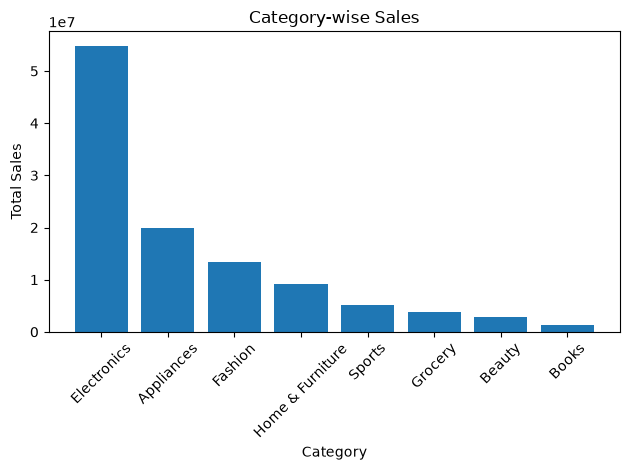

In [87]:

plt.bar(x=cat_sales.index,height=cat_sales['Sales'])

plt.title('Category-wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
cat_sales.values

array([[54861340.39],
       [19847848.49],
       [13428682.57],
       [ 9158473.82],
       [ 5215570.84],
       [ 3781929.14],
       [ 2754154.61],
       [ 1233452.3 ]])

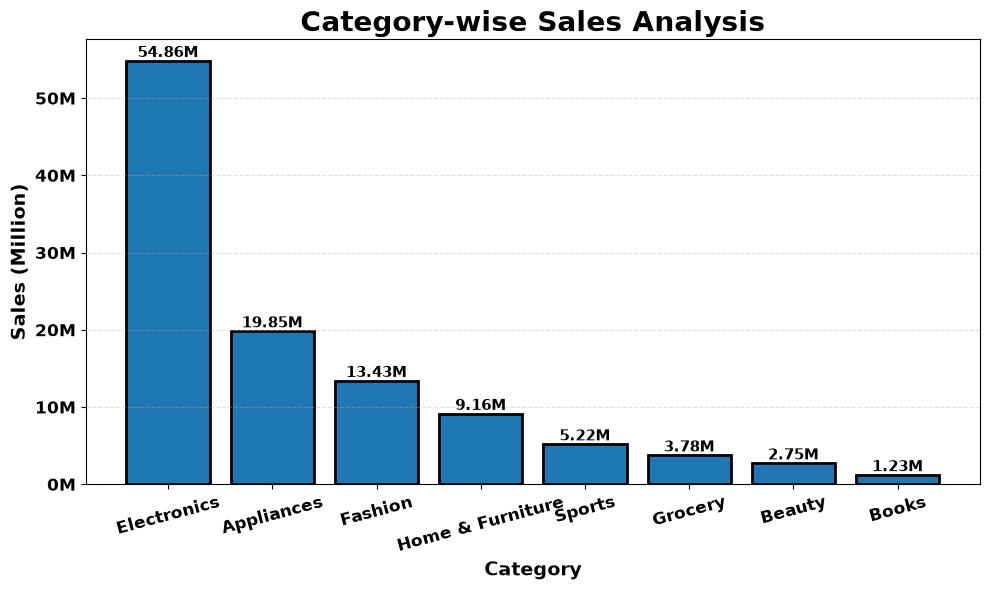

In [89]:
import matplotlib.ticker as ticker


# Category-wise Sales
cat_sales = df.pivot_table(values='Sales',
                           index='Category',
                           aggfunc='sum').sort_values(by='Sales', ascending=False)


plt.figure(figsize=(10,6))


bars = plt.bar(cat_sales.index,
               cat_sales['Sales'],
               edgecolor='black',
               linewidth=2)


# Title and Labels (Bold)
plt.title("Category-wise Sales Analysis",
          fontsize=20, fontweight='bold')


plt.xlabel("Category",
           fontsize=14, fontweight='bold')


plt.ylabel("Sales (Million)",
           fontsize=14, fontweight='bold')


# Y-axis in Millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)


# Bold X & Y ticks
plt.xticks(fontsize=12, fontweight='bold', rotation=15)
plt.yticks(fontsize=12, fontweight='bold')


# Value labels on bars (Millions)
for bar in bars:
    value = bar.get_height()/1e6
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{value:.2f}M",
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')


plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



 #Electronics is the highest-selling category with 54.86 Million in sales.
Appliances ranks second with 19.77 Million in sales.
Fashion generated 13.41 Million in sales.
Home & Furniture recorded the lowest sales among the displayed categories at 9.16 Million.
The chart clearly shows that Electronics contributes the largest share of overall sales, indicating it is the company's strongest-performing category. 





In [90]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [91]:
# Region wise Sales

In [92]:
region_sales=df.pivot_table(values='Sales',
                            index='Region',
                            aggfunc='sum').sort_values(by='Sales',ascending=False)

In [93]:
region_sales

,Sales
Region,
South,"35,935,892.14"
West,"34,003,763.35"
North,"27,606,622.47"
East,"7,603,808.30"
Central,"3,751,865.69"
Northeast,"1,379,500.21"


In [94]:
# horizentL 

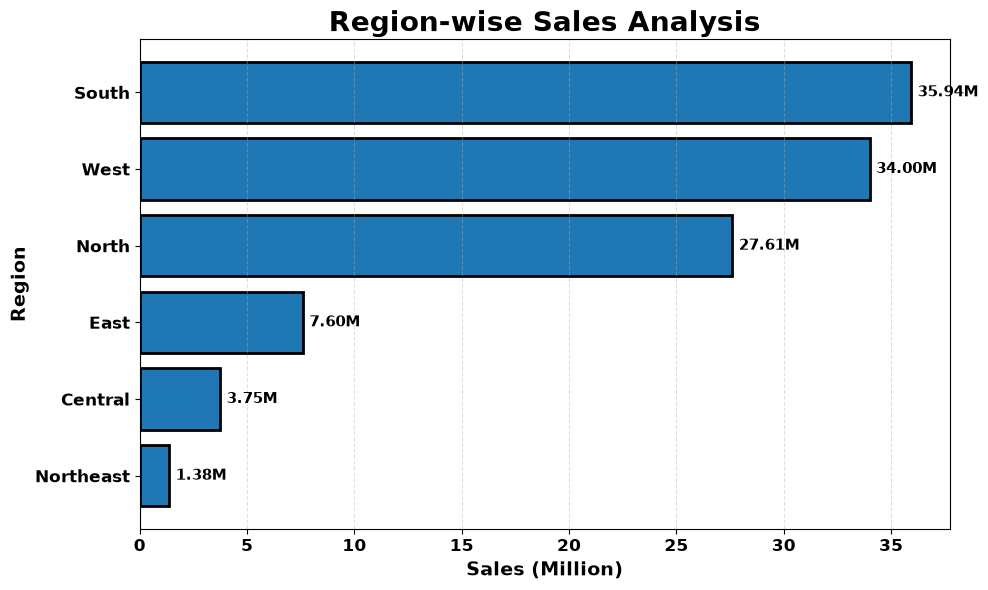

In [95]:
# Sort ascending for horizontal bar chart
plot_data = region_sales.sort_values(by='Sales', ascending=True)


plt.figure(figsize=(10, 6))


bars = plt.barh(
    plot_data.index,
    plot_data['Sales'] / 1e6,
    edgecolor='black',
    linewidth=2
)


# Title and labels
plt.title(
    'Region-wise Sales Analysis',
    fontsize=20,
    fontweight='bold'
)


plt.xlabel(
    'Sales (Million)',
    fontsize=14,
    fontweight='bold'
)


plt.ylabel(
    'Region',
    fontsize=14,
    fontweight='bold'
)


# Bold tick labels
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')


# Add values at end of bars
for bar in bars:
    width = bar.get_width()


    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}M',
        va='center',
        fontsize=11,
        fontweight='bold'
    )


plt.grid(axis='x', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()



South is the highest-performing region with 35.93M in sales, followed closely by West with 33.99M. North also performs strongly with 27.52M. However, sales drop significantly in East (7.60M), Central (3.75M), and Northeast (1.38M).
The major insight is that sales are heavily concentrated in South, West, and North, while Northeast is the weakest-performing region. The business should investigate the reasons behind strong performance in the top three regions and consider targeted marketing campaigns, product availability, promotions, and customer acquisition strategies to improve sales in East, Central, and especially Northeast. 


In [96]:
# which categories do customer buy most often
# (order** frequancy**, which is very diffrent from revenue)

In [97]:
print(df['Category'].value_counts())

Category
Fashion             3250
Grocery             2597
Beauty              1939
Electronics         1864
Home & Furniture    1502
Appliances           813
Books                806
Sports               764
Name: count, dtype: int64


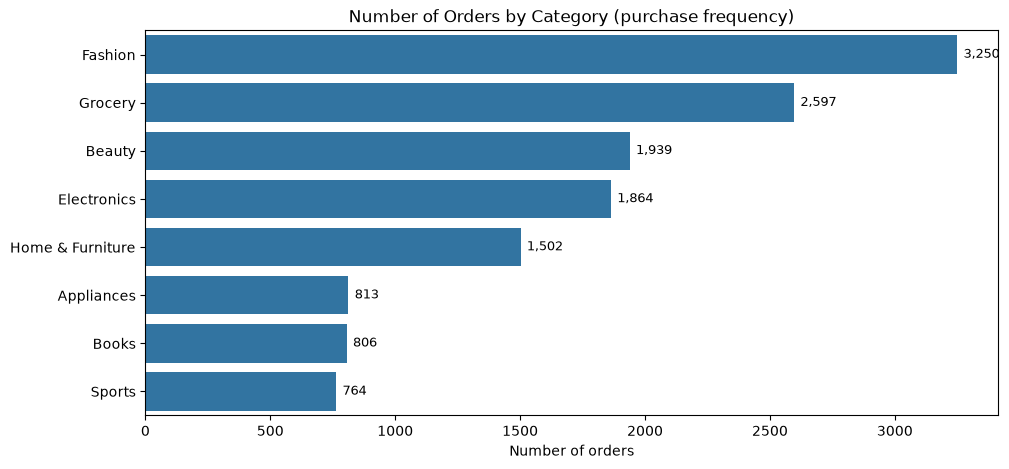

Category
Fashion             3250
Grocery             2597
Beauty              1939
Electronics         1864
Home & Furniture    1502
Appliances           813
Books                806
Sports               764
Name: count, dtype: int64


In [98]:
plt.figure(figsize=(11, 5))
order = df["Category"].value_counts().index
ax = sns.countplot(data=df, y="Category", order=order)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 25, p.get_y() + p.get_height()/2),
                va="center", fontsize=9)
plt.title("Number of Orders by Category (purchase frequency)")
plt.xlabel("Number of orders"); plt.ylabel("")
plt.show()


print(df["Category"].value_counts())


Category
Fashion             3250
Grocery             2597
Beauty              1939
Electronics         1864
Home & Furniture    1502
Appliances           813
Books                806
Sports               764
Name: count, dtype: int64


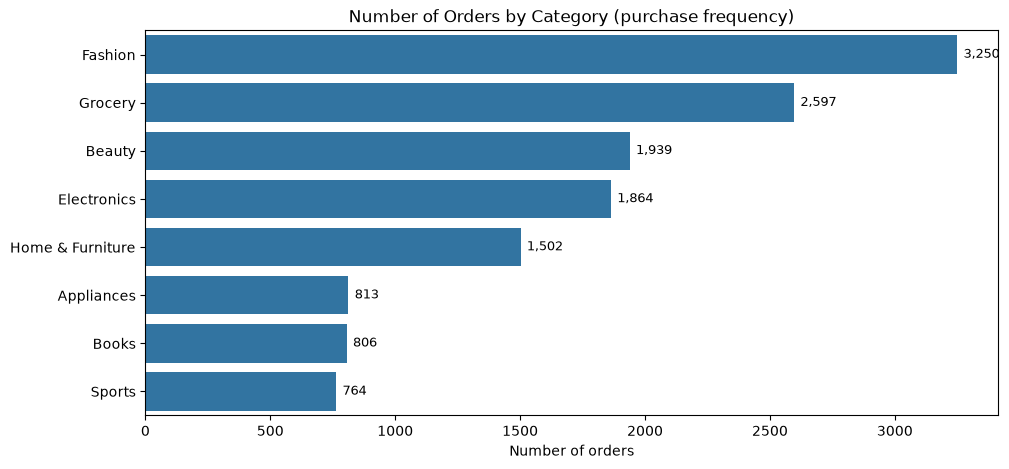

Category
Fashion             3250
Grocery             2597
Beauty              1939
Electronics         1864
Home & Furniture    1502
Appliances           813
Books                806
Sports               764
Name: count, dtype: int64


In [99]:
print(df["Category"].value_counts())
plt.figure(figsize=(11, 5))
order = df["Category"].value_counts().index
ax = sns.countplot(data=df, y="Category", order=order)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 25, p.get_y() + p.get_height()/2),
                va="center", fontsize=9)
plt.title("Number of Orders by Category (purchase frequency)")
plt.xlabel("Number of orders"); plt.ylabel("")
plt.show()


print(df["Category"].value_counts())


Fashion is the most frequently purchased category with 3,246 orders, followed by Grocery with 2,594 orders. Beauty and Electronics also have relatively high purchase frequency, with 1,937 and 1,864 orders, respectively.
An important insight comes from comparing this with your previous category-wise sales analysis: Fashion has the highest order frequency, but Electronics generates the highest sales revenue (54.86M). This suggests that Electronics has a much higher average transaction/order value, whereas Fashion is purchased more frequently but at comparatively lower values 


NAVY  = "#0B1B34"     # primary
GOLD  = "#C9A227"     # accent
TEAL  = "#12807E"
RED   = "#B3261E"
GREY  = "#6B7280"





In [100]:
# State wise total sales

In [101]:
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

State
Maharashtra     24,888,849.13
Karnataka       12,898,767.22
Delhi           11,708,753.73
Tamil Nadu      10,304,327.64
Gujarat          9,114,914.22
Telangana        7,819,325.99
Haryana          5,362,441.64
Uttar Pradesh    4,977,078.82
Kerala           4,913,471.29
West Bengal      4,459,158.71
Name: Sales, dtype: float64

In [102]:
%pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
import plotly.express as px


# -------------------------------
# 1. State-wise Total Sales
# -------------------------------


state_sales = (
    df.groupby('State', as_index=False)['Sales']
      .sum()
      .sort_values('Sales', ascending=False)
)


# Sales in Millions
state_sales['Sales_Million'] = state_sales['Sales'] / 1_000_000




# -------------------------------
# 2. Custom Color Palette
# -------------------------------


NAVY = "#0B1B34"
GOLD = "#C9A227"
TEAL = "#12807E"
RED  = "#B3261E"
GREY = "#6B7280"


# Additional colors for other states
colors = [
    NAVY,
    GOLD,
    TEAL,
    RED,
    GREY,
    "#3B82F6",   # Blue
    "#8B5CF6",   # Purple
    "#F97316",   # Orange
    "#10B981",   # Green
    "#EC4899",   # Pink
    "#06B6D4",   # Cyan
    "#84CC16",   # Lime
    "#F59E0B",   # Amber
    "#6366F1",   # Indigo
    "#14B8A6"    # Light Teal
]

# -------------------------------
# 3. Plotly Donut Chart
# -------------------------------

fig = px.pie(
    state_sales,
    names='State',
    values='Sales_Million',
    hole=0.55,
    color_discrete_sequence=colors,
    title='State-wise Total Sales'
)


# -------------------------------
# 4. Formatting
# -------------------------------


fig.update_traces(
    textposition='inside',
    textinfo='percent+label',


    hovertemplate=
        '<b>%{label}</b><br>' +
        'Sales: %{value:.2f}M<br>' +
        'Share: %{percent}<extra></extra>',


    marker=dict(
        line=dict(
            color='white',
            width=2
        )
    )
)


fig.update_layout(


    title=dict(
        text='<b>State-wise Total Sales</b>',
        x=0.5,
        xanchor='center',
        font=dict(
            size=24,
            color=NAVY
        )
    ),


    legend=dict(
        title='<b>State</b>',
        font=dict(size=12)
    ),


    font=dict(
        size=13
    ),


    width=1000,
    height=650
)


fig.show()



Maharashtra is the highest-performing state with approximately 24.88M in total sales, making it the strongest market in the dataset. Karnataka and Delhi follow as the next major contributors, while Tamil Nadu also shows strong sales performance.
Sales decline considerably for states such as Uttar Pradesh, Kerala, and West Bengal compared with the leading states. This indicates that revenue is concentrated in a few high-performing states.
Business Insight: The company should maintain strong customer engagement and product availability in Maharashtra and other leading states, while using targeted promotions, localized marketing, and improved distribution strategies to increase sales in lower-performing states. 


In [104]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [105]:
#  most use payment method 

In [106]:
df['Payment_Method'].value_counts()

Payment_Method
Upi                 5377
Credit Card         2427
Debit Card          1745
Cash On Delivery    1476
Net Banking          866
Emi                  865
Wallet               779
Name: count, dtype: int64

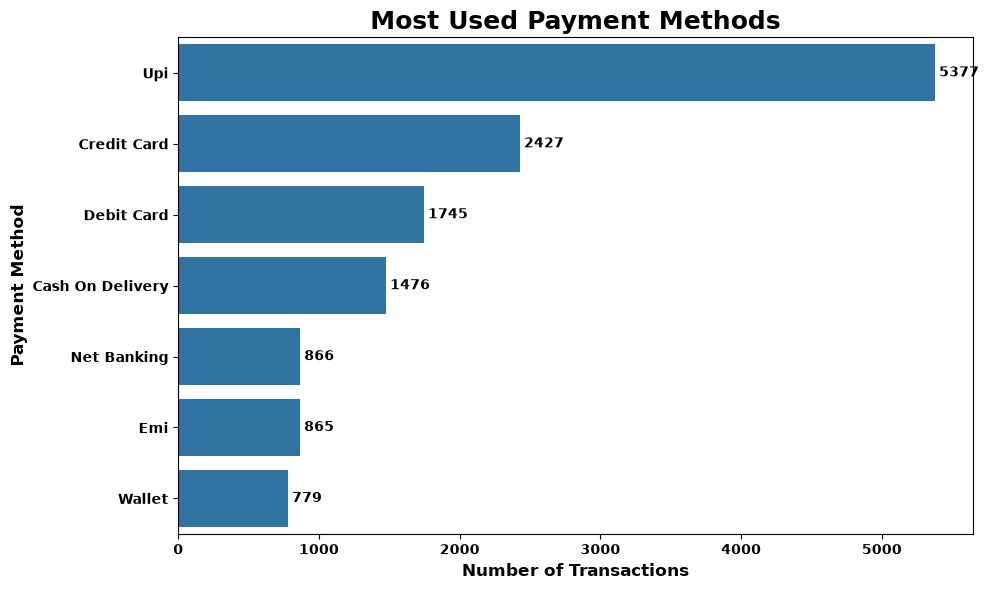

In [107]:
payment_counts = df['Payment_Method'].value_counts().reset_index()
payment_counts.columns = ['Payment_Method', 'Count']


plt.figure(figsize=(10, 6))


ax = sns.barplot(
    data=payment_counts,
    x='Count',
    y='Payment_Method'
)


# Title and labels
plt.title(
    'Most Used Payment Methods',
    fontsize=18,
    fontweight='bold'
)


plt.xlabel('Number of Transactions', fontsize=12, fontweight='bold')
plt.ylabel('Payment Method', fontsize=12, fontweight='bold')


# Bold tick labels
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')


# Values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10,
        fontweight='bold'
    )


plt.tight_layout()
plt.show()



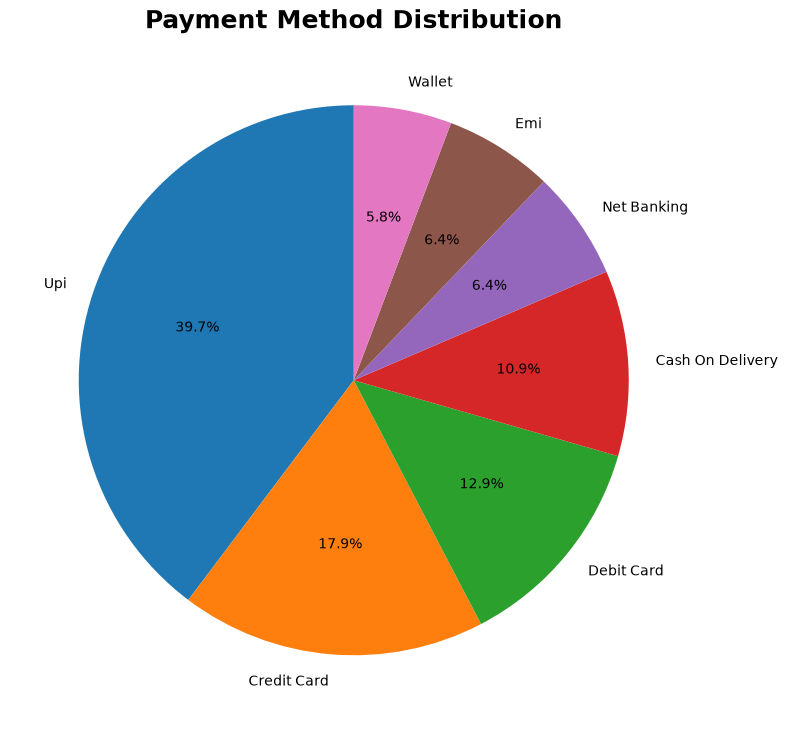

In [108]:
# Payment method counts
payment_counts = df['Payment_Method'].value_counts()


plt.figure(figsize=(8, 8))


plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)


plt.title(
    'Payment Method Distribution',
    fontsize=18,
    fontweight='bold'
)


plt.tight_layout()
plt.show()



Conclusion – Payment Method Distribution (%)
UPI – 39.7% → Most preferred payment method.
Credit Card – 17.9% → Second most popular.
Debit Card – 12.9%
Cash on Delivery – 10.9%
Net Banking – 6.4%
EMI – 6.4%
Wallet – 5.8% → Least used payment method.
Business Insight: UPI alone accounts for nearly 40% of all transactions, showing a strong customer preference for fast and convenient digital payments. 


In [109]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [110]:
df['Order_Status'].value_counts()

Order_Status
Delivered    11619
Returned       771
Shipped        688
Cancelled      457
Name: count, dtype: int64

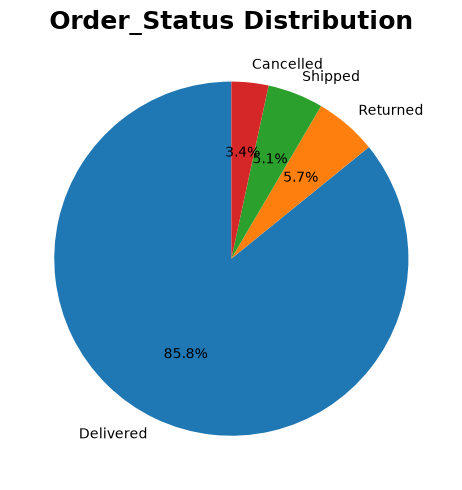

In [111]:
# Payment method counts
Order_Status= df['Order_Status'].value_counts()


plt.figure(figsize=(5, 5))


plt.pie(
    Order_Status.values,
    labels=Order_Status.index,
    autopct='%1.1f%%',
    startangle=90
)


plt.title(
    'Order_Status Distribution',
    fontsize=18,
    fontweight='bold'
)


plt.tight_layout()
plt.show()


The chart shows that the majority of orders (85.8%) were successfully delivered, indicating a strong overall fulfillment rate.
Delivered: 85.8% — dominant order status.
Returned: 5.7% — a relatively small but important portion of orders.
Shipped: 5.1% — orders currently in transit.
Cancelled: 3.4% — the smallest share.
Key Insight: With 85.8% delivered orders, the business demonstrates good delivery performance. However, the 5.7% return rate should be investigated to identify causes such as product quality, incorrect orders, or customer dissatisfaction. 


### Top 10 products by revenue

In [112]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [113]:
prod = (df.groupby(["Product_Name", "Category"])
          .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"),
               Orders=("Order_ID", "count"), Units=("Quantity", "sum"))
          .reset_index())
prod["Margin_%"] = (prod["Profit"] / prod["Revenue"] * 100).round(1)
top10 = prod.sort_values("Revenue", ascending=False).head(10)


In [114]:
top10

,Product_Name,Category,Revenue,Profit,Orders,Units,Margin_%
26,Hp Pavilion 15,Electronics,"14,002,179.05","-200,259.64",183,237,-1.40
34,Lenovo Ideapad Slim 3,Electronics,"9,958,010.69","-107,153.25",185,241,-1.10
13,Canon Eos 1500D,Electronics,"7,780,106.66","424,248.12",173,213,5.50
4,Apple Watch Se,Electronics,"7,168,602.66","-147,388.41",186,227,-2.10
48,Oneplus Nord Ce4,Electronics,"5,457,678.07","-10,980.06",189,323,-0.20
54,Samsung Galaxy M35,Electronics,"4,849,666.26","90,240.94",210,256,1.90
63,Voltas 1.5T Split Ac,Appliances,"3,821,564.98","188,149.32",98,115,4.90
52,Redmi Note 13 5G,Electronics,"3,738,957.44","61,141.46",191,237,1.60
28,Ifb 6.5Kg Front Load,Appliances,"3,674,139.25","112,679.16",102,118,3.10
36,Lg 260L Double Door Fridge,Appliances,"3,449,637.27","235,655.52",108,122,6.80


In [115]:
# bar chart

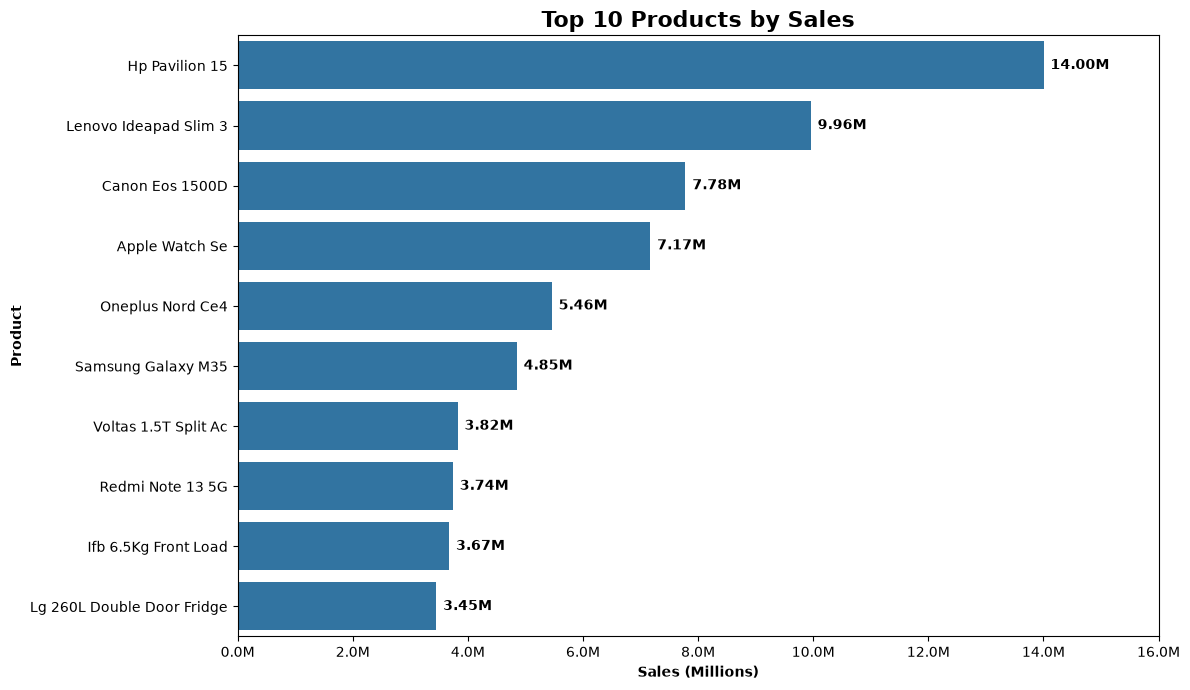

In [116]:
# Sort Top 10 for horizontal bar chart
plot_data = top10.sort_values("Revenue", ascending=False)


plt.figure(figsize=(12, 7))


ax = sns.barplot(
    data=plot_data,
    x="Revenue",
    y="Product_Name"
)


# Add sales labels in Millions
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1_000_000:.2f}M' for v in container.datavalues],
        padding=5,
        fontsize=10,
        fontweight='bold'
    )


plt.title(
    "Top 10 Products by Sales",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel("Sales (Millions)", fontweight="bold")
plt.ylabel("Product", fontweight="bold")


plt.xticks(
    ticks=ax.get_xticks(),
    labels=[f'{x/1_000_000:.1f}M' for x in ax.get_xticks()]
)


plt.tight_layout()
plt.show()



HP Pavilion 15 is the highest-selling product with approximately 14.0M in sales, followed by Lenovo IdeaPad Slim 3 (9.96M) and Canon EOS 1500D (7.78M).
However, high sales do not always mean high profitability. HP Pavilion 15 generates the highest revenue but records approximately 200K negative profit with a −1.4% profit margin, whereas Canon EOS 1500D maintains a positive 5.5% margin.
Key Insight: Electronics dominate the Top 10 products by sales. The business should focus on both sales growth and profitability, especially improving margins on high-revenue products. 


In [117]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age'],
      dtype='str')

In [118]:
#  Time Series Analysis

In [119]:
df["Year"]=df["Order_Date"].dt.year

In [120]:
year_Sales=pd.pivot_table(data=df,values='Sales',index='Year')

In [121]:
year_Sales

,Sales
Year,
2024,"8,311.16"
2025,"8,000.54"


In [122]:
df['Year']

0        2024
1        2025
2        2024
3        2025
4        2025
         ... 
13535    2024
13536    2025
13537    2024
13538    2025
13539    2025
Name: Year, Length: 13535, dtype: int32

In [123]:
# pie chart

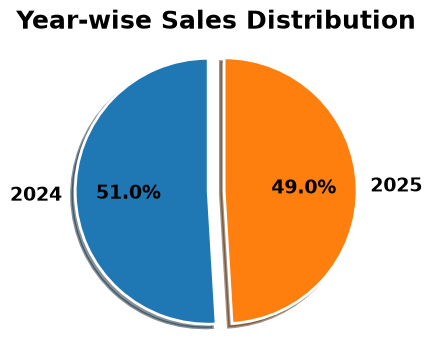

In [ ]:
plt.figure(figsize=(4, 4))

plt.pie(
    year_Sales['Sales'],
    labels=year_Sales.index,
    autopct='%1.1f%%',
    explode=[0.06] * len(year_Sales),
    shadow=True,
    startangle=90,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)


plt.title(
    'Year-wise Sales Distribution',
    fontsize=18,
    fontweight='bold'
)


plt.axis('equal')
plt.show()

 

2024 contributes approximately 50.9% of total sales, compared with 49.1% in 2025. Sales declined slightly in 2025, indicating that overall performance remained relatively stable but experienced a small year-on-year decrease. 


In [125]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age', 'Year'],
      dtype='str')

In [127]:
# device type 

In [129]:
df['Device_Type'].value_counts()

Device_Type
Mobile App    7870
Desktop       2706
Mobile Web    2316
Tablet         643
Name: count, dtype: int64

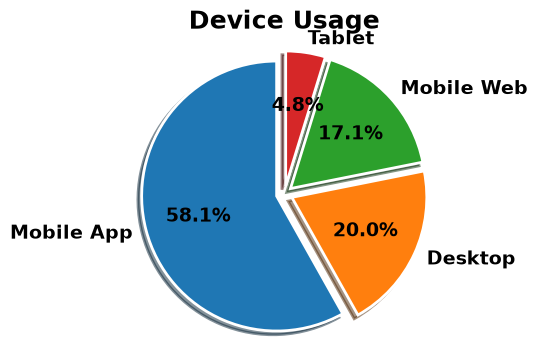

In [132]:
plt.figure(figsize=(4, 4))
s1=df['Device_Type'].value_counts()
plt.pie(
    s1.values,
    labels=s1.index,
    autopct='%1.1f%%',
    explode=[0.06] * len(s1),
    shadow=True,
    startangle=90,
    textprops={'fontsize': 14, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)


plt.title(
    'Device Usage',
    fontsize=18,
    fontweight='bold'
)


plt.axis('equal')
plt.show()

 

Mobile App is the dominant device type, accounting for approximately 58.1% of records. Desktop contributes around 20.0%, followed by Mobile Web at 17.1%, while Tablet has the smallest share at approximately 4.7%.
Key Insight: Most customers interact through the Mobile App, indicating that the business should prioritize mobile-app performance, usability, and customer experience. 


In [133]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age', 'Year'],
      dtype='str')

In [134]:
df['Customer_Rating'].value_counts()

Customer_Rating
5.00    2133
4.50    1025
4.40     979
4.60     979
4.70     930
4.30     929
4.20     873
4.80     856
4.10     791
4.90     733
4.00     602
3.90     544
3.80     423
3.70     359
3.60     305
3.50     221
3.40     177
3.30     148
3.20     123
3.10      92
3.00      74
2.90      61
2.80      44
2.70      37
2.50      27
2.60      25
2.40      11
2.30      10
2.00       5
2.20       4
2.10       3
6.00       3
0.00       2
1.80       2
1.10       1
1.00       1
1.40       1
1.90       1
7.50       1
Name: count, dtype: int64

In [135]:
rating=pd.pivot_table(data=df,values='Customer_Rating',index='Product_Name',aggfunc='mean')

In [141]:
rating.nlargest(10,'Customer_Rating')

,Customer_Rating
Product_Name,
Aashirvaad Atta 10Kg,4.46
India Gate Basmati Rice 5Kg,4.44
Kore Dumbbell Set 20Kg,4.44
Mamaearth Onion Shampoo,4.43
Lg 260L Double Door Fridge,4.43
Ncert Class 12 Bundle,4.42
Bru Instant Coffee 200G,4.42
Atomic Habits,4.41
Minimalist Vitamin C Serum,4.41


In [142]:
# bar chart

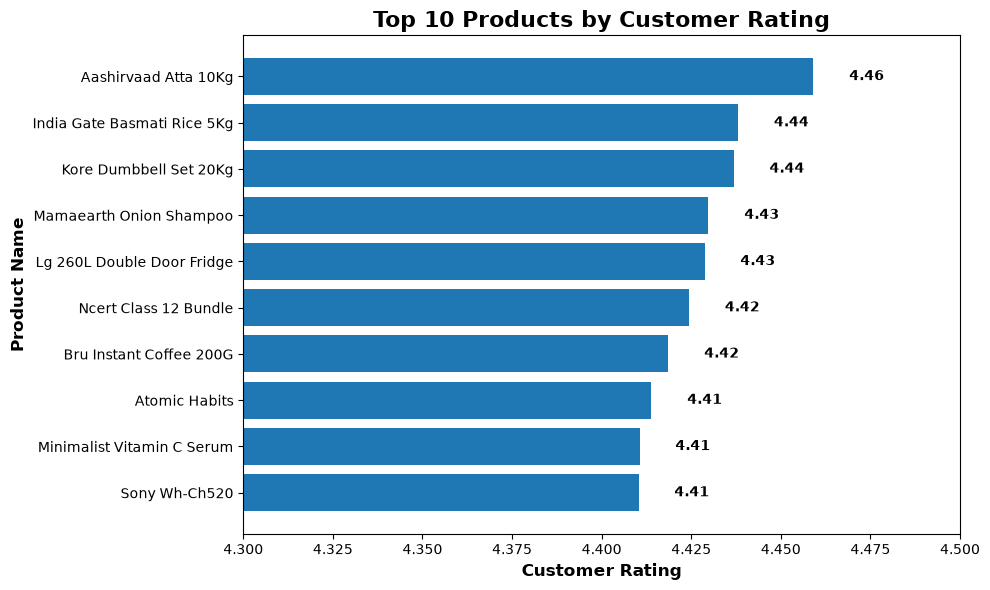

In [144]:
top_rating = rating.nlargest(10, 'Customer_Rating')


plt.figure(figsize=(10, 6))


bars = plt.barh(
    top_rating.index,
    top_rating['Customer_Rating']
)


# Show rating on bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center',
        fontweight='bold'
    )


plt.xlabel('Customer Rating', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')


plt.title(
    'Top 10 Products by Customer Rating',
    fontsize=16,
    fontweight='bold'
)


# Zoom into relevant rating range
plt.xlim(4.3, 4.5)


plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Aashirvaad Atta 10Kg has the highest customer rating at 4.46, making it the best-rated product among the Top 10.
India Gate Basmati Rice 5Kg and Kore Dumbbell Set 20Kg jointly rank next with ratings of 4.44, followed by Mamaearth Onion Shampoo and LG 260L Double Door Fridge at 4.43.
All Top 10 products have ratings between 4.41 and 4.46, showing consistently high customer satisfaction with very little variation.
Key Insight: The narrow rating range suggests that several products are performing strongly in customer satisfaction; the business can study the highest-rated products to identify factors driving positive customer experiences. 




In [ ]:
# low rating product >> nsmallest 

In [147]:
rating.nsmallest(10,'Customer_Rating')

,Customer_Rating
Product_Name,
W Printed Palazzo Set,4.25
Wildcraft Laptop Backpack,4.25
Fastrack Casual Watch,4.27
Allen Solly Formal Shirt,4.27
Puma Running Shoes,4.29
Biba Anarkali Kurta,4.29
Us Polo Assn Polo T-Shirt,4.29
Bata Formal Shoes,4.30
Nilkamal Study Table,4.30


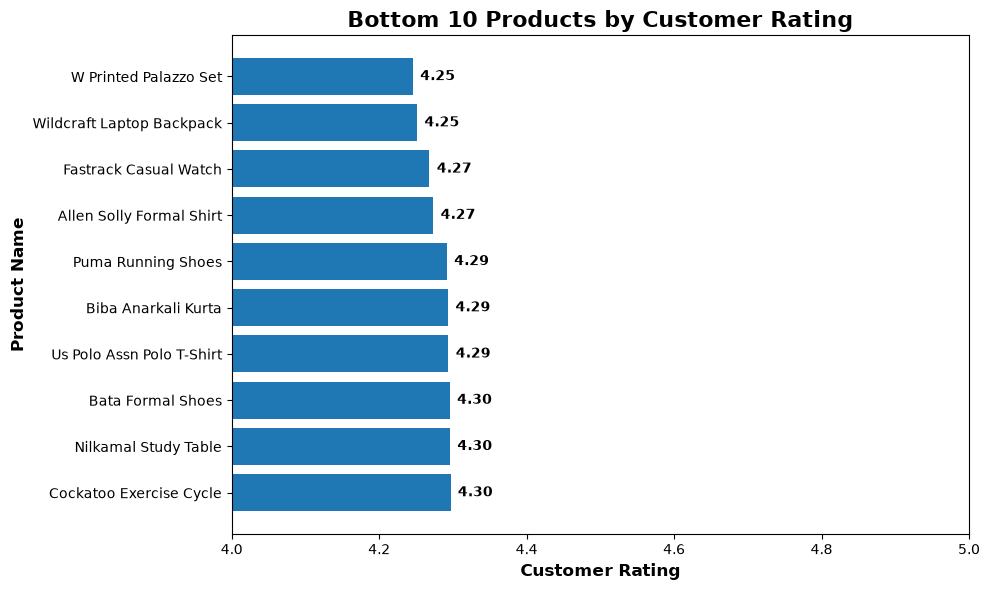

In [152]:
low_rating = rating.nsmallest(10, 'Customer_Rating')


plt.figure(figsize=(10, 6))


bars = plt.barh(
    low_rating.index,
    low_rating['Customer_Rating']
)


# Show rating on bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center',
        fontweight='bold'
    )


plt.xlabel('Customer Rating', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')


plt.title(
    'Bottom 10 Products by Customer Rating',
    fontsize=16,
    fontweight='bold'
)


# Zoom into relevant rating range
plt.xlim(4.0, 5.0)


plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


W Printed Palazzo Set and Wildcraft Laptop Backpack have the lowest customer ratings at 4.25 among the Bottom 10 products.
Fastrack Casual Watch and Allen Solly Formal Shirt follow with ratings of 4.27, while Puma Running Shoes and US Polo Assn Polo T-Shirt have ratings of 4.29.
The remaining products — Bata Formal Shoes, Nilkamal Study Table, Cockatoo Exercise Cycle, and Titan Neo Analog Watch — have ratings of 4.30.
Key Insight: Even the lowest-rated products have ratings between 4.25 and 4.30, indicating that overall customer satisfaction remains relatively high. However, the business should analyze customer feedback for the lowest-rated products to identify areas for improvemen 


In [153]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'City', 'State', 'Region', 'Latitude', 'Longitude',
       'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales', 'Cost', 'Profit', 'Profit_Margin',
       'Payment_Method', 'Order_Status', 'Delivery_Days', 'Customer_Rating', 'Customer_Segment', 'Device_Type', 'age', 'Year'],
      dtype='str')

In [154]:
df['Customer_Segment']

0          Premium
1        Corporate
2          Premium
3          Regular
4          Premium
           ...    
13535      Premium
13536      Regular
13537      Regular
13538       Budget
13539       Budget
Name: Customer_Segment, Length: 13535, dtype: str

In [155]:
df['Customer_Segment'].value_counts()

Customer_Segment
Regular      4516
Premium      4209
Budget       3326
Corporate    1484
Name: count, dtype: int64

 most of the customer are Regular and premimum customer 

In [ ]:
# location
# map /state wise total sales


In [159]:
import plotly.express as px


# State-wise total sales
state_sales = df.groupby('State', as_index=False).agg({
    'Sales': 'sum',
    'Latitude': 'mean',
    'Longitude': 'mean'
})


# Create map
fig = px.scatter_map(
    state_sales,
    lat='Latitude',
    lon='Longitude',
    size='Sales',
    color='Sales',
    hover_name='State',
    hover_data={'Sales': ':,.0f'},
    size_max=45,
    zoom=3.5,
    center={'lat': 22.5, 'lon': 79},
    color_continuous_scale='YlOrRd',
    title='<b>State-wise Total Sales in India</b>'
)


fig.update_layout(
    height=700,
    title_x=0.5,
    title_font_size=22,
    margin=dict(l=0, r=0, t=60, b=0)
)


fig.show()


In [160]:
state_sales

,State,Sales,Latitude,Longitude
0,Assam,"1,379,500.21",26.14,91.74
1,Bihar,"1,229,140.11",25.59,85.14
2,Chandigarh,"1,140,483.99",30.73,76.78
3,Delhi,"11,708,753.73",28.70,77.10
4,Gujarat,"9,114,914.22",22.26,72.68
5,Haryana,"5,362,441.64",28.46,77.03
6,Karnataka,"12,898,767.22",12.87,77.45
7,Kerala,"4,913,471.29",9.30,76.57
8,Madhya Pradesh,"3,751,865.69",22.95,76.51
9,Maharashtra,"24,888,849.13",19.13,74.12
